In [4]:
import polars as pl
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os 

train_data_pl = pl.read_csv(r"../data/train.csv",encoding="shift_jis")

In [5]:
import mlflow

In [6]:

from FeatureEngineer import FeatureEngineer
from FullPipelineModel import FullPipelineModel
from MoisturePipeline import MoisturePipeline

In [7]:
mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("exp4")

<Experiment: artifact_location='/mlruns/2', creation_time=1776943007761, experiment_id='2', last_update_time=1776943007761, lifecycle_stage='active', name='exp4', tags={}>

In [8]:
with mlflow.start_run() as run:
    pipe_path = "pipe.pkl"

    pipe = MoisturePipeline(
        use_pca=False,
        use_diff=False,
        use_conv=False,
        use_band=False,
        use_sg=True,
        params={
        "verbosity": -1,
        "n_estimators": 1000,
        "learning_rate": 0.03,
        "num_leaves": 6,
        "max_depth": 3,
        "min_data_in_leaf": 30,   #重要
        "feature_fraction": 0.7,
        "bagging_fraction": 0.7,
        "bagging_freq": 1,
        "n_jobs": -1,
        }
    )

    rmse = pipe.fit(train_data_pl)

    with open("pipe.pkl", "wb") as f:#保存用
        pickle.dump(pipe, f)
        
    assert os.path.exists(pipe_path)
    
    mlflow.log_artifact(pipe_path)
    mlflow.log_params({
        **pipe.params,
        "use_conv": pipe.use_conv,
        "use_diff": pipe.use_diff,
        "use_band": pipe.use_band,
        "use_pca": pipe.use_pca,
        "use_sg": pipe.use_sg,
    })
    mlflow.log_metric("rmse", rmse)

    
    mlflow.pyfunc.log_model(
        python_model=FullPipelineModel(None),
        artifact_path="model",
        artifacts={"pipe": pipe_path}
    )

    
    """
    try:
        mlflow.pyfunc.log_model(
            name="model",
            python_model=FullPipelineModel(None),
            #artifact_path="model",
            artifacts={"pipe": pipe_path}
        )
    except:
        print("ERRROERRRRRRRRR!!!!!!")
        print("run_id:", run.info.run_id)
    """

Fold 0: RMSE = 18.9329
Fold 1: RMSE = 14.6822
Fold 2: RMSE = 48.8547
Fold 3: RMSE = 21.6219
Fold 4: RMSE = 14.6071


In [9]:
run_id = run.info.run_id
print(run_id)

737bec3dc432488bbf706debb856d092


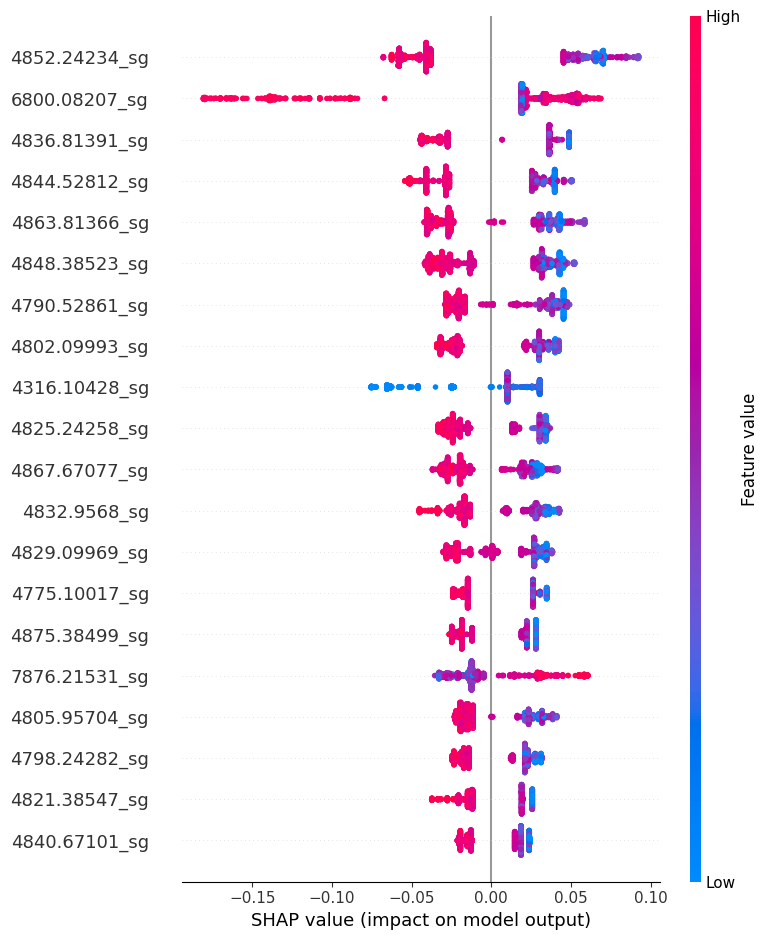


=== SHAP importance ===
4852.24234_sg    0.053958
6800.08207_sg    0.053656
4836.81391_sg    0.036865
4844.52812_sg    0.034352
4863.81366_sg    0.033737
4848.38523_sg    0.032044
4790.52861_sg    0.028342
4802.09993_sg    0.028070
4316.10428_sg    0.026527
4825.24258_sg    0.026409
4867.67077_sg    0.024190
4832.9568_sg     0.024026
4829.09969_sg    0.023215
4775.10017_sg    0.021965
4875.38499_sg    0.021464
7876.21531_sg    0.021017
4805.95704_sg    0.020422
4798.24282_sg    0.020223
4821.38547_sg    0.019090
4840.67101_sg    0.017690
dtype: float64


In [10]:
from ml_pipeline import FeatureEngineer  # 定義している場所からimport

# SHAP可視化

shap_importance = pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)

#pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)

In [11]:
print(len(pipe.fe.feature_cols))

print(len(pipe.fe.original_base_cols))

print(len(pipe.fe.first_diff_cols))

print(len(pipe.fe.band_feature))

print(len(pipe.fe.sg_feature_cols))

3110
1555
0
0
1555


# 提出

In [12]:
test_data_pl = pl.read_csv(r"../data/test.csv",encoding="shift_jis")

In [13]:
print(run_id)

737bec3dc432488bbf706debb856d092


In [14]:
model = mlflow.pyfunc.load_model(f"runs:/{run_id}/model")
print(model._model_impl.python_model.pipe)

In [15]:
y_pred = model.predict(test_data_pl)

In [16]:
submission = pd.DataFrame({
    "id": test_data_pl["sample number"],
    "含水率": y_pred
})

submission.head()
submission.to_csv(r"../data/submission.csv",index=False,header = False)